Can we use past weather data to predict future condiitons?



In [15]:
#Install libraries
!pip install seaborn scikit-learn


In [18]:
#Imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#URL for data 
url = "https://zenodo.org/records/4770937/files/weather_prediction_dataset.csv" 
#load data into python dataframe
df = pd.read_csv(url)
print(df.head())

       DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0  20000101      1                  8            0.89          1.0286   
1  20000102      1                  8            0.87          1.0318   
2  20000103      1                  5            0.81          1.0314   
3  20000104      1                  7            0.79          1.0262   
4  20000105      1                  5            0.90          1.0246   

   BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                    0.20                 0.03             0.0   
1                    0.25                 0.00             0.0   
2                    0.50                 0.00             3.7   
3                    0.63                 0.35             6.9   
4                    0.51                 0.07             3.7   

   BASEL_temp_mean  BASEL_temp_min  ...  STOCKHOLM_temp_min  \
0              2.9             1.6  ...                -9.3   
1              3.6             2.7  ..

In [19]:
 #disply basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Columns: 165 entries, DATE to TOURS_temp_max
dtypes: float64(150), int64(15)
memory usage: 4.6 MB
None


In [20]:
#display summary statistics for the dataset
print(df.describe())

               DATE        MONTH  BASEL_cloud_cover  BASEL_humidity  \
count  3.654000e+03  3654.000000        3654.000000     3654.000000   
mean   2.004568e+07     6.520799           5.418446        0.745107   
std    2.874287e+04     3.450083           2.325497        0.107788   
min    2.000010e+07     1.000000           0.000000        0.380000   
25%    2.002070e+07     4.000000           4.000000        0.670000   
50%    2.004567e+07     7.000000           6.000000        0.760000   
75%    2.007070e+07    10.000000           7.000000        0.830000   
max    2.010010e+07    12.000000           8.000000        0.980000   

       BASEL_pressure  BASEL_global_radiation  BASEL_precipitation  \
count     3654.000000             3654.000000          3654.000000   
mean         1.017876                1.330380             0.234849   
std          0.007962                0.935348             0.536267   
min          0.985600                0.050000             0.000000   
25%       

In [21]:
#check missing values in the dataset
print(df.isnull().sum())

DATE                      0
MONTH                     0
BASEL_cloud_cover         0
BASEL_humidity            0
BASEL_pressure            0
                         ..
TOURS_global_radiation    0
TOURS_precipitation       0
TOURS_temp_mean           0
TOURS_temp_min            0
TOURS_temp_max            0
Length: 165, dtype: int64


In [23]:
#data pre processing 
#prepare data for modeling 

#handle missing values 
df=df.dropna()


In [24]:
#perform on-hgot encoding on categorical variables
df=pd.get_dummies(df, drop_first=True)

In [25]:
#feature selection 
#select relevant features for the model
X = df.drop("BASEL_temp_mean", axis=1)
y = df["BASEL_temp_mean"]

In [26]:
#split the data into training and testing sets
from sklearn.model_selection import train_test_split
#spit the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
#build and train the model
from sklearn.linear_model import LinearRegression
#initialize the model
model = LinearRegression()
#train the model
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
#evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
#make predictions on the test set
y_pred = model.predict(X_test)
#calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
#calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')


Mean Squared Error: 0.19665724668464116
R-squared: 0.9963551645217822


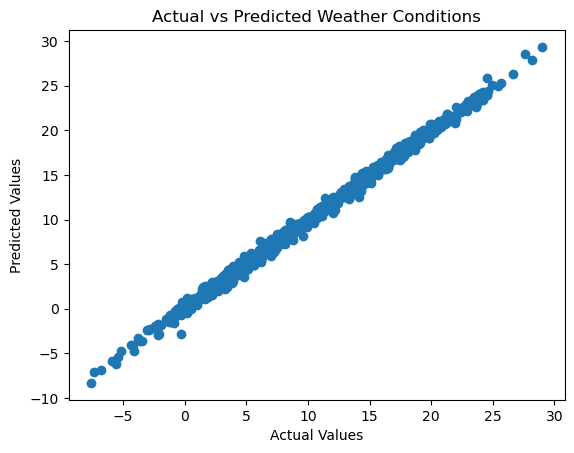

In [30]:
#visualize the results
import matplotlib.pyplot as plt
#plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Weather Conditions')
plt.show()
